# 🧭 Original strategy: adaptive regime ensemble

## 🧭 tl;dr

This is an original portfolio rule built from the strongest recurring ideas in the library: cross-sectional momentum, 52-week-high proximity, absolute trend filters, inverse-volatility weighting, and a defensive fallback. It is inspired by research showing that relative momentum and trend signals can complement risk-based allocation, but the exact combination and ETF implementation are ours.

> Educational research only. Not financial advice. This notebook is a hypothesis, not a claim of a discovered market law.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #EFF6FF; border-radius: 8px;"><strong>🧑‍🏫 Reader guide</strong><br>Follow the signal components separately, then see how the ensemble chooses assets and how often it moves to defensive ETFs. The important comparison is against ordinary 12–1 momentum and SPY in the untouched test period.</div>


## 📚 Research motivation and hypothesis

The library’s earlier tests produced three recurring observations:

- momentum can work, but it is vulnerable to reversals and crashes;
- 52-week-high proximity is a different way to describe trend strength;
- inverse volatility can improve portfolio balance, but it is not a return guarantee.

A related academic asset-allocation paper by Clare, Seaton, Smith, and Thomas studies combining momentum with trend following and risk parity. See [The Trend Is Our Friend](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2265693).

**Hypothesis:** a portfolio that requires an asset to have both strong relative momentum and a healthy absolute trend, then weights selected assets by inverse volatility, may produce a smoother out-of-sample path than raw momentum. When too few assets qualify, the portfolio should prefer a small defensive basket rather than force a risky selection.


In [1]:

from pathlib import Path
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    if (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    elif "__file__" in globals():
        ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_data, load_price_panel, make_demo_ohlcv
from src.portfolio import run_portfolio_backtest
from src.research import metrics_for_period

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:

def load_panel():
    tickers = ["SPY", "QQQ", "EFA", "EEM", "TLT", "IEF", "LQD", "GLD", "DBC", "VNQ", "XLE", "XLK", "XLF"]
    try:
        panel = load_price_panel(tickers, "2006-01-01", "2026-01-01")
        source = "Yahoo Finance adjusted daily ETF closes"
    except Exception as exc:
        demo = make_demo_ohlcv(periods=5_000, seed=1102, start="2006-01-01")["close"]
        panel = pd.DataFrame({ticker: demo * (1.0 + 0.015 * i) for i, ticker in enumerate(tickers)}, index=demo.index)
        source = f"deterministic demo ETF panel fallback ({type(exc).__name__})"
    return panel.dropna(), source


close, data_source = load_panel()
print(f"Data source: {data_source}")
print(f"Observations: {len(close):,} | {close.index.min().date()} to {close.index.max().date()}")
display(close.head())


Data source: Yahoo Finance adjusted daily ETF closes
Observations: 5,008 | 2006-02-06 to 2025-12-31


,DBC,EEM,EFA,GLD,IEF,LQD,QQQ,SPY,TLT,VNQ,XLE,XLF,XLK
Date,,,,,,,,,,,,,
2006-02-06,19.185097,21.803122,33.987099,56.720001,48.517426,47.331638,34.846832,86.932266,47.462036,27.023010,15.481534,17.145826,8.176646
2006-02-07,18.630159,21.231087,33.735302,54.599998,48.458908,47.212315,34.693146,86.163185,47.237812,26.810503,14.835324,17.032133,8.153527
2006-02-08,18.550879,21.297094,33.855721,54.830002,48.429638,47.212315,35.094448,86.946014,47.128334,26.691500,14.838071,17.140411,8.311513
2006-02-09,18.725290,21.352093,33.921410,56.180000,48.476463,47.287445,34.761429,86.801773,47.342106,26.818996,14.499843,17.183731,8.272980
2006-02-10,18.384401,21.319096,33.844776,54.790001,48.336014,47.199059,34.974915,86.959724,47.081409,26.844501,14.447598,17.281174,8.338484


## 📜 Exact rules

At each month start, using data available before that decision:

1. Calculate 12–1 momentum: a 252-day return skipping the most recent 21 days.
2. Calculate 52-week-high proximity: prior close divided by its prior 252-day high.
3. Require price to be above its 200-day moving average.
4. Rank eligible assets by the average of their cross-sectional momentum rank and high-proximity rank.
5. Select the top four eligible assets and weight them in inverse proportion to 60-day volatility.
6. If fewer than four assets qualify, fill the portfolio with TLT, IEF, and GLD using inverse-volatility weights.
7. Hold until the next monthly rebalance; charge 10 bps per unit of turnover.

The rule is deliberately simple enough to audit. No parameter was selected by looking at the final test period.


In [3]:

def adaptive_regime_weights(close, momentum_window=252, skip_recent=21, high_window=252, trend_window=200, volatility_window=60, top_n=4):
    prior = close.shift(1)
    momentum = prior.shift(skip_recent).pct_change(momentum_window)
    high_proximity = prior / prior.rolling(high_window, min_periods=high_window).max()
    trend_ok = prior > prior.rolling(trend_window, min_periods=trend_window).mean()
    volatility = prior.pct_change().rolling(volatility_window, min_periods=volatility_window).std()
    momentum_rank = momentum.rank(axis=1, pct=True)
    high_rank = high_proximity.rank(axis=1, pct=True)
    score = (momentum_rank + high_rank) / 2.0
    defensive = [ticker for ticker in ["TLT", "IEF", "GLD"] if ticker in close.columns]

    month = close.index.to_period("M")
    month_start = pd.Series(month, index=close.index).ne(pd.Series(month, index=close.index).shift(1))
    candidates = pd.DataFrame(0.0, index=close.index, columns=close.columns)
    decision_label = pd.Series("uninitialized", index=close.index, dtype="object")
    for timestamp in close.index[month_start.to_numpy()]:
        valid = score.loc[timestamp].where(trend_ok.loc[timestamp]).dropna().sort_values(ascending=False)
        selected = valid.head(top_n).index
        if len(selected) < top_n:
            selected = pd.Index(defensive)
            decision_label.loc[timestamp] = "defensive fallback"
        else:
            decision_label.loc[timestamp] = "risk-on ensemble"
        risk = volatility.loc[timestamp, selected].replace(0.0, np.nan).dropna()
        if len(risk):
            inverse = 1.0 / risk
            candidates.loc[timestamp, inverse.index] = inverse / inverse.sum()

    weights = pd.DataFrame(np.nan, index=close.index, columns=close.columns)
    weights.loc[month_start] = candidates.loc[month_start]
    weights = weights.ffill().fillna(0.0)
    decision_label = decision_label.replace("uninitialized", np.nan).ffill().fillna("warm-up")
    return weights, decision_label, score, trend_ok


def twelve_one_weights(close, top_n=4):
    score = close.shift(21).pct_change(252)
    month = close.index.to_period("M")
    month_start = pd.Series(month, index=close.index).ne(pd.Series(month, index=close.index).shift(1))
    candidates = pd.DataFrame(0.0, index=close.index, columns=close.columns)
    for timestamp in close.index[month_start.to_numpy()]:
        valid = score.loc[timestamp].dropna()
        if len(valid) >= top_n:
            selected = valid.nlargest(top_n).index
            candidates.loc[timestamp, selected] = 1.0 / top_n
    weights = pd.DataFrame(np.nan, index=close.index, columns=close.columns)
    weights.loc[month_start] = candidates.loc[month_start]
    return weights.ffill().fillna(0.0)


adaptive_weights, decision_label, score, trend_ok = adaptive_regime_weights(close)
momentum_weights = twelve_one_weights(close)
adaptive = run_portfolio_backtest(close, adaptive_weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
momentum = run_portfolio_backtest(close, momentum_weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
spy_hold = run_portfolio_backtest(close, pd.DataFrame({"SPY": 1.0, **{ticker: 0.0 for ticker in close.columns if ticker != "SPY"}}, index=close.index), transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
splits = split_time_series(close)
periods = {name: frame.index for name, frame in splits.items()}


## 📈 Results and implementation behavior

In [4]:

rows = []
for name, backtest in [("Adaptive regime ensemble", adaptive), ("12–1 momentum", momentum), ("SPY buy & hold", spy_hold)]:
    for period_name, period_index in periods.items():
        metrics = metrics_for_period(backtest, period_index)
        rows.append({"strategy": name, "period": period_name, **metrics})
summary = pd.DataFrame(rows).set_index(["strategy", "period"])
display(summary[["annualized_return", "annualized_volatility", "sharpe_ratio", "sortino_ratio", "max_drawdown", "calmar_ratio", "annualized_turnover", "number_of_trades", "total_return_after_costs"]].style.format({"annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "sortino_ratio": "{:.2f}", "max_drawdown": "{:.2%}", "calmar_ratio": "{:.2f}", "annualized_turnover": "{:.2f}", "number_of_trades": "{:.0f}", "total_return_after_costs": "{:.2%}"}))


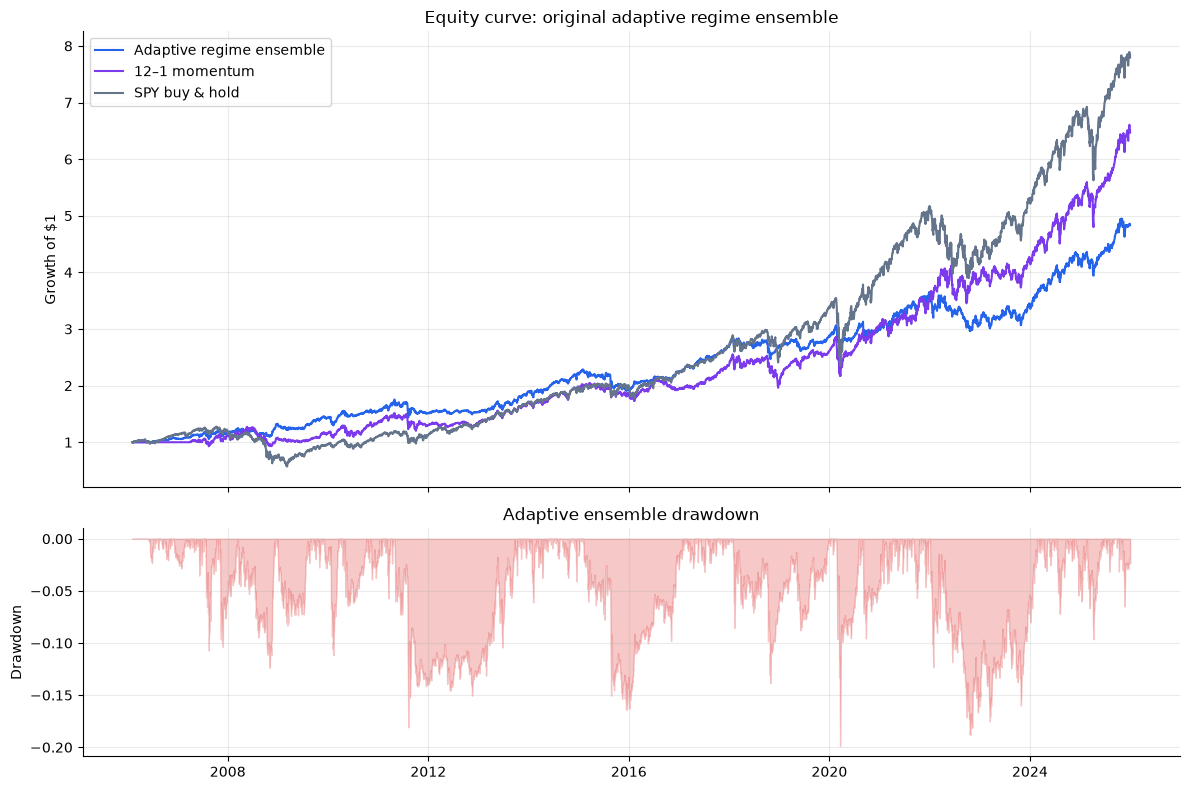

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for backtest, label, color in [(adaptive, "Adaptive regime ensemble", "#2563EB"), (momentum, "12–1 momentum", "#7C3AED"), (spy_hold, "SPY buy & hold", "#64748B")]:
    axes[0].plot(backtest.frame.index, backtest.frame.equity / backtest.frame.equity.iloc[0], label=label, color=color)
axes[0].set_title("Equity curve: original adaptive regime ensemble")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[1].fill_between(adaptive.frame.index, adaptive.frame.drawdown, 0, color="#DC2626", alpha=0.25)
axes[1].set_title("Adaptive ensemble drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()


In [6]:

behavior = pd.Series({
    "fraction risk-on": (decision_label == "risk-on ensemble").mean(),
    "fraction defensive fallback": (decision_label == "defensive fallback").mean(),
    "average held gross exposure": adaptive.held_weights.abs().sum(axis=1).mean(),
})
display(behavior.to_frame("value").style.format("{:.2%}"))


,value
fraction risk-on,86.70%
fraction defensive fallback,13.30%
average held gross exposure,98.38%


## 🧪 Robustness and stress checks

The original rule is fixed at four assets, a 252-day momentum window, a 200-day trend filter, and a 60-day volatility estimate. The grid below changes only the number of selected assets and the trend window, ranking on validation before showing the untouched test period.


In [7]:

grid_rows = []
for top_n, trend_window in itertools.product([3, 4, 5], [150, 200, 250]):
    candidate_weights, _, _, _ = adaptive_regime_weights(close, trend_window=trend_window, top_n=top_n)
    candidate = run_portfolio_backtest(close, candidate_weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
    validation = metrics_for_period(candidate, periods["validation"])
    test = metrics_for_period(candidate, periods["test"])
    grid_rows.append({"top_n": top_n, "trend_window": trend_window, "validation_sharpe": validation["sharpe_ratio"], "validation_return": validation["annualized_return"], "test_sharpe": test["sharpe_ratio"], "test_return": test["annualized_return"], "test_drawdown": test["max_drawdown"]})
sensitivity = pd.DataFrame(grid_rows).sort_values("validation_sharpe", ascending=False)
display(sensitivity.style.format({"validation_sharpe": "{:.2f}", "validation_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_return": "{:.2%}", "test_drawdown": "{:.2%}"}))


,top_n,trend_window,validation_sharpe,validation_return,test_sharpe,test_return,test_drawdown
6,5,150,0.80,9.27%,0.29,2.77%,-24.73%
7,5,200,0.75,8.63%,0.32,3.08%,-24.44%
8,5,250,0.72,8.15%,0.57,6.29%,-17.61%
0,3,150,0.71,9.90%,0.63,8.47%,-18.30%
3,4,150,0.70,8.76%,0.49,5.58%,-24.74%
4,4,200,0.61,7.41%,0.61,7.34%,-18.31%
5,4,250,0.61,7.39%,0.58,6.88%,-18.31%
1,3,200,0.57,7.63%,0.68,9.19%,-16.60%
2,3,250,0.55,7.42%,0.66,8.88%,-16.60%


In [8]:

stress_rows = []
for label, (start, end) in {"2008 crisis": ("2008-01-01", "2009-12-31"), "2020 shock": ("2020-02-01", "2020-06-30"), "2022 inflation": ("2022-01-01", "2022-12-31")}.items():
    index = close.loc[start:end].index
    for name, backtest in [("Adaptive regime ensemble", adaptive), ("12–1 momentum", momentum), ("SPY buy & hold", spy_hold)]:
        metrics = metrics_for_period(backtest, index)
        stress_rows.append({"window": label, "strategy": name, "return": metrics["total_return_after_costs"], "sharpe": metrics["sharpe_ratio"], "drawdown": metrics["max_drawdown"]})
display(pd.DataFrame(stress_rows).style.format({"return": "{:.2%}", "sharpe": "{:.2f}", "drawdown": "{:.2%}"}))


,window,strategy,return,sharpe,drawdown
0,2008 crisis,Adaptive regime ensemble,22.20%,0.99,-12.37%
1,2008 crisis,12–1 momentum,4.14%,0.20,-26.98%
2,2008 crisis,SPY buy & hold,-20.14%,-0.15,-51.87%
3,2020 shock,Adaptive regime ensemble,-1.51%,-0.08,-19.88%
4,2020 shock,12–1 momentum,-2.59%,-0.02,-24.08%
5,2020 shock,SPY buy & hold,-3.17%,0.08,-33.72%
6,2022 inflation,Adaptive regime ensemble,-14.70%,-0.95,-18.77%
7,2022 inflation,12–1 momentum,11.27%,0.62,-16.15%
8,2022 inflation,SPY buy & hold,-18.18%,-0.71,-24.50%


## ⚖️ What went well / what went wrong

### ✅ What went well

- The ensemble combines signals that have different failure modes: relative momentum, absolute trend, and volatility-aware sizing.
- The defensive fallback is explicit instead of silently forcing a risk-on position.
- The comparison with 12–1 momentum shows whether the extra complexity earns its keep.

### ⚠️ What went wrong or remains uncertain

- Combining several familiar signals can create the appearance of originality without adding independent information.
- Rank averaging and thresholds are design choices that can be overfit.
- The ETF universe is small and contains broad markets, sectors, commodities, and bonds with different histories.
- Inverse-volatility weights can concentrate in assets with temporarily low measured volatility.

**Bottom line:** this is a good research candidate only if its out-of-sample improvement is persistent and economically understandable. Complexity alone is not an achievement.
